# 04 — Forecasting Models

We build a **seasonal-naive baseline first**, then three ML models of increasing complexity, using a single held-out final test window (the last 60 days of the dataset) so every model is compared on exactly the same unseen future period. A separate, more rigorous multi-fold time-series evaluation is done in `05_model_evaluation.ipynb`.

**Note on XGBoost:** this sandboxed build environment has no internet access, so the `xgboost` package (listed in `requirements.txt` for real use) can't be installed here. We use scikit-learn's `HistGradientBoostingRegressor` instead — a native histogram-based gradient boosting implementation with the same algorithmic family as XGBoost/LightGBM. Swapping in `xgboost.XGBRegressor` is a one-line change (see the commented-out import below) once you run this locally.

In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
# from xgboost import XGBRegressor  # use this instead of HistGradientBoostingRegressor when running locally with internet access

from features import FEATURE_COLUMNS, TARGET_COLUMN
from forecasting import seasonal_naive_predict
from evaluation import evaluate

df = pd.read_csv("../data/model_features.csv", parse_dates=["date"])
df.shape

(35360, 22)

## Train / test split — chronological, not random

We hold out the **last 60 days** of the dataset as a final test set. Training uses only rows strictly before the test window starts. This is the opposite of `train_test_split(..., random_state=42)`, which would shuffle days randomly and let the model 'see the future' during training for some products — an unrealistic and misleadingly optimistic setup for a forecasting problem.

In [2]:
TEST_DAYS = 60
max_date = df["date"].max()
test_start = max_date - pd.Timedelta(days=TEST_DAYS - 1)

train = df[df["date"] < test_start].copy()
test = df[df["date"] >= test_start].copy()

print(f"Train: {train['date'].min().date()} to {train['date'].max().date()}  ({len(train)} rows)")
print(f"Test:  {test['date'].min().date()} to {test['date'].max().date()}  ({len(test)} rows)")
assert train["date"].max() < test["date"].min()

Train: 2023-01-29 to 2025-05-01  (32960 rows)
Test:  2025-05-02 to 2025-06-30  (2400 rows)


## Model 0 — Seasonal Naive baseline

Predict today's demand using demand from the same weekday, one week ago (`lag_7`, already in our feature table). No fitting at all — this is the bar every ML model has to clear to be worth using.

In [3]:
y_test = test[TARGET_COLUMN].values
pred_naive = test["lag_7"].values

results = {}
results["Seasonal Naive"] = evaluate(y_test, pred_naive)
results["Seasonal Naive"]

{'MAE': 23.129, 'RMSE': 34.249, 'sMAPE_%': 28.58}

## Model 1 — Regularized Linear Regression (Ridge)

In [4]:
X_train, y_train = train[FEATURE_COLUMNS], train[TARGET_COLUMN]
X_test = test[FEATURE_COLUMNS]

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
pred_ridge = np.clip(ridge.predict(X_test), 0, None)

results["Ridge Regression"] = evaluate(y_test, pred_ridge)
results["Ridge Regression"]

{'MAE': 16.642, 'RMSE': 23.816, 'sMAPE_%': 21.14}

## Model 2 — Random Forest

Only features available at prediction time are used (same `FEATURE_COLUMNS` as every other model — no target leakage).

In [5]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    n_jobs=-1, random_state=42,
)
rf.fit(X_train, y_train)
pred_rf = np.clip(rf.predict(X_test), 0, None)

results["Random Forest"] = evaluate(y_test, pred_rf)
results["Random Forest"]

{'MAE': 15.815, 'RMSE': 22.999, 'sMAPE_%': 20.06}

## Model 3 — Gradient Boosting (XGBoost-equivalent)

In [6]:
gbm = HistGradientBoostingRegressor(
    max_depth=6, learning_rate=0.05, max_iter=400,
    l2_regularization=1.0, random_state=42,
)
gbm.fit(X_train, y_train)
pred_gbm = np.clip(gbm.predict(X_test), 0, None)

results["Gradient Boosting"] = evaluate(y_test, pred_gbm)
results["Gradient Boosting"]

{'MAE': 15.788, 'RMSE': 23.019, 'sMAPE_%': 20.05}

## Comparison on the held-out 60-day test window

In [7]:
results_df = pd.DataFrame(results).T
results_df = results_df[["MAE", "RMSE", "sMAPE_%"]].sort_values("MAE")
results_df

                      MAE    RMSE  sMAPE_%
Gradient Boosting  15.788  23.019    20.05
Random Forest      15.815  22.999    20.06
Ridge Regression   16.642  23.816    21.14
Seasonal Naive     23.129  34.249    28.58

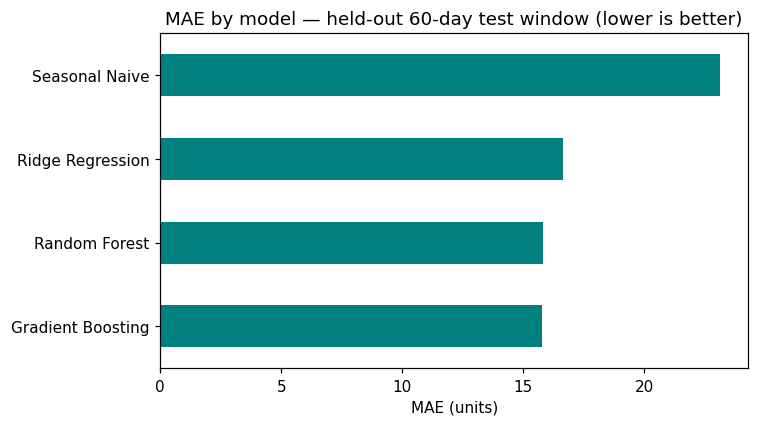

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
results_df["MAE"].sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_title("MAE by model — held-out 60-day test window (lower is better)")
ax.set_xlabel("MAE (units)")
plt.tight_layout()
plt.savefig("../reports/figures/08_model_comparison_mae.png", dpi=110)
plt.show()

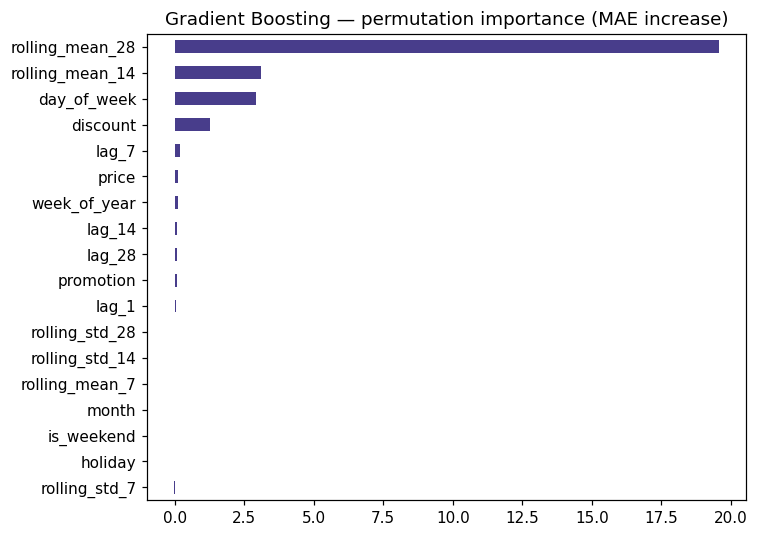

In [9]:
# HistGradientBoostingRegressor doesn't expose .feature_importances_ directly
# (unlike RandomForest/XGBoost), so we use permutation importance: shuffle one
# feature at a time on the test set and measure how much MAE gets worse.
from sklearn.inspection import permutation_importance

perm = permutation_importance(gbm, X_test, y_test, n_repeats=5, random_state=42,
                               scoring="neg_mean_absolute_error", n_jobs=-1)
importances = pd.Series(perm.importances_mean, index=FEATURE_COLUMNS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind="barh", ax=ax, color="darkslateblue")
ax.invert_yaxis()
ax.set_title("Gradient Boosting — permutation importance (MAE increase)")
plt.tight_layout()
plt.savefig("../reports/figures/09_feature_importance.png", dpi=110)
plt.show()

In [10]:
predictions = test[["product_id", "date", TARGET_COLUMN]].copy()
predictions["pred_seasonal_naive"] = pred_naive
predictions["pred_ridge"] = pred_ridge
predictions["pred_random_forest"] = pred_rf
predictions["pred_gradient_boosting"] = pred_gbm
predictions.to_csv("../data/test_predictions.csv", index=False)
results_df.to_csv("../reports/model_comparison_holdout.csv")
predictions.head()

    product_id       date  ...  pred_random_forest  pred_gradient_boosting
824       P001 2025-05-02  ...          107.085518              106.104415
825       P001 2025-05-03  ...          140.965912              140.983241
826       P001 2025-05-04  ...          150.974407              152.444544
827       P001 2025-05-05  ...          110.414175              103.205152
828       P001 2025-05-06  ...           99.853318              109.515165

[5 rows x 7 columns]

## Discussion

- The seasonal-naive baseline is *not* trivial to beat on this dataset — it already
  captures the weekly seasonality directly. Any ML model that doesn't clear it isn't
  adding value, and the comparison table above is the evidence for whether ours do.
- Ridge regression is linear and can't capture interactions (e.g. "promotion effect
  differs by category"); tree-based models can.
- Random Forest and Gradient Boosting use identical feature sets — differences in
  their scores come from *how* they combine the features (bagged deep trees vs.
  boosted shallow trees), not from access to different information.
- All models were clipped to non-negative predictions, since demand can't be negative.